In [2]:
import time
import os
import gc
import math
import cv2
import numpy as np
import pandas as pd
import pyautogui as pa
import shutil
import imageio

import re  # regex
from PIL import Image, ImageDraw
import random
from scipy.stats import sem, ttest_ind, norm, ttest_ind_from_stats
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression
from sklearn.cluster import KMeans
from scipy.interpolate import UnivariateSpline

from lib.analysis.trace_metrics import TraceMetrics
from lib.analysis.false_discovery_control import false_discovery_control
from lib.auto_GUI.auto_PhotoZ import AutoPhotoZ
from lib.analysis.laminar_dist import *
from lib.analysis.align import ImageAlign
from lib.file.ROI_writer import ROIFileWriter
from lib.analysis.barrel_roi import Barrel_ROI_Creator
from lib.analysis.cell_roi import RandomROISample, OverlapCounterROI
from lib.analysis.baseline_correction import BaselineCorrection

# 2-way ANOVA for medial and lateral PPR vs IPI
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm

from lib.utilities import *
from lib.file.TIF import *

from ZDA_Adventure.utility import ROIFileReader




In [3]:
# Load data, not from Drive for Desktop since PhotoZ complains about loading zda from Drive
data_dir = "C:/Users/jjudge3/Desktop/Data/slow_NBQX/"
barrels_df = data_dir + 'export_summary_barrels.csv'
px_df = data_dir + 'export_summary_single_px.csv'
direct_df = data_dir + 'export_summary_direct_stim.csv'
single_px_df = data_dir + 'export_summary_single_px.csv'
four_px_df = data_dir + 'export_summary_4_px.csv'
nine_px_df = data_dir + 'export_summary_9_px.csv'
camera_program = 4
um_per_px = 6.0 #um
output_fig_dir = 'P:/John/neurophotonics-paper/input/'

roi_selection = 'barrels' # options: 'barrels', 'single_px', 'four_px', 'nine_px'

# load the CSVs
barrels_df = pd.read_csv(barrels_df)
px_df = pd.read_csv(px_df)
direct_df = pd.read_csv(direct_df)
single_px_df = pd.read_csv(single_px_df)
four_px_df = pd.read_csv(four_px_df)
nine_px_df = pd.read_csv(nine_px_df)
# add column for Coronal/Sagittal
barrels_df['Section'] = 'Coronal'
px_df['Section'] = 'Coronal'
direct_df['Section'] = 'Coronal'
single_px_df['Section'] = 'Coronal'
four_px_df['Section'] = 'Coronal'
nine_px_df['Section'] = 'Coronal'

# choice barrels or single px df
dfs = [barrels_df] #, single_px_df, px_df, direct_df]

if roi_selection == 'single_px':
    dfs = [single_px_df]
elif roi_selection == 'barrels':
    dfs = [barrels_df]
elif roi_selection == 'four_px':
    dfs = [four_px_df]
elif roi_selection == 'nine_px':
    dfs = [nine_px_df]

In [4]:
def read_array_file(filename): 
    data_arr = pd.read_csv(filename,
                                 sep='\t',
                                 header=None,
                                 names=['Index',  'Values'])
    return np.array(data_arr['Values']).reshape((80, 80))

def read_dat_trace_file(filename):
    data_arr = pd.read_csv(filename,
                                 sep='\t',
                                 header=0)  # change me to traces?
    data_arr = data_arr.apply(pd.to_numeric, errors='coerce')
    return data_arr

In [5]:
# load catalog
catalog = data_dir + "meta_catalog.csv"
catalog_df = pd.read_csv(catalog)
catalog_df

,Date,Slice,Location,Recording,time,NBQX_conc,infusion_time
0,2/6/2026,1,2,3,1:00,0.00,NaN
1,2/6/2026,1,2,4,1:03,0.00,NaN
2,2/6/2026,1,2,5,1:20,0.83,1:04
3,2/6/2026,1,2,6,1:23,0.83,1:04
4,2/6/2026,1,2,7,1:27,0.83,1:04
...,...,...,...,...,...,...,...
229,3/12/2026,1,1,19,4:51,5.00,4:46
230,3/12/2026,1,1,20,4:53,5.00,4:46
231,3/12/2026,1,1,21,4:55,5.00,4:46
232,3/12/2026,1,1,22,4:57,5.00,4:46


In [6]:

# merge catalog info into the barrels_df and px_df
for df in dfs + [direct_df, nine_px_df]:
    df['time'] = ''
    df['NBQX_conc'] = np.nan
    # infusion time is time
    df['infusion_time'] = ''
    for index, row in df.iterrows():
        # look up the corresponding catalog entry and add the time, NBQX_conc, and infustion_time to the df
        date = row['Date']
        slic = row['Slice']
        loc = row['Location']
        rec = row['Recording']

        if '-' in date:
            date = date.replace('-', '/')
        if len(date.split('/')) < 2:
            print(f"Invalid date format for {date}")
            continue
        if len(date.split('/')[2]) == 2:
            date = date[:-2] + '20' + date[-2:]
        catalog_entry = catalog_df[(catalog_df['Date'] == date) &
                                   (catalog_df['Slice'] == int(slic)) &
                                   (catalog_df['Location'] == int(loc)) &
                                   (catalog_df['Recording'] == int(rec))]
        if len(catalog_entry) == 0:
            print(f"No catalog entry found for {date}, {slic}, {loc}, {rec}")
            print("only options:", catalog_df['Date'].unique())
            continue
        elif len(catalog_entry) > 1:
            print(f"Multiple catalog entries found for {date}, {slic}, {loc}, {rec}")
            continue
        else:
            catalog_entry = catalog_entry.iloc[0]
            df.at[index, 'time'] = catalog_entry['time']
            df.at[index, 'NBQX_conc'] = catalog_entry['NBQX_conc']
            df.at[index, 'infusion_time'] = catalog_entry['infusion_time']
df

,ROI,amp,latency,stim_time,halfwidth,X_Center,Y_Center,ROI_Set,Date,Slice,Location,Recording,trace,amp_array,latency_array,Stim_Layer,Section,time,NBQX_conc,infusion_time
0,1,0.001470,50.702039,49.633276,6.565214,46,30,1_2_rois_output__masked_grid_0,2/6/2026,1,2,3,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,L4,Coronal,1:00,0.0,NaN
1,2,0.001593,50.876512,49.633276,5.831293,45,33,1_2_rois_output__masked_grid_0,2/6/2026,1,2,3,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,L4,Coronal,1:00,0.0,NaN
2,3,0.001438,50.729432,49.633276,7.176721,45,36,1_2_rois_output__masked_grid_0,2/6/2026,1,2,3,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,L4,Coronal,1:00,0.0,NaN
3,4,0.001606,50.823786,49.633276,5.221240,46,38,1_2_rois_output__masked_grid_0,2/6/2026,1,2,3,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,L4,Coronal,1:00,0.0,NaN
4,5,0.001493,51.071149,49.633276,6.256688,48,30,1_2_rois_output__masked_grid_0,2/6/2026,1,2,3,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,L4,Coronal,1:00,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24324,25,0.003101,49.351701,49.553221,31.995151,26,31,2_1rois_output__masked_grid_3,3/6/2026,2,1,29,C:/Users/jjudge3/Desktop/Data/slow_NBQX/L23\03...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/L23\03...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/L23\03...,L2/3,Coronal,5:26,10.0,4:56
24325,26,0.001773,49.351673,49.553221,13.116391,30,20,2_1rois_output__masked_grid_3,3/6/2026,2,1,29,C:/Users/jjudge3/Desktop/Data/slow_NBQX/L23\03...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/L23\03...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/L23\03...,L2/3,Coronal,5:26,10.0,4:56
24326,27,0.001210,48.173910,49.553221,2.193523,30,23,2_1rois_output__masked_grid_3,3/6/2026,2,1,29,C:/Users/jjudge3/Desktop/Data/slow_NBQX/L23\03...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/L23\03...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/L23\03...,L2/3,Coronal,5:26,10.0,4:56
24327,28,0.001593,57.973968,49.553221,3.703815,30,26,2_1rois_output__masked_grid_3,3/6/2026,2,1,29,C:/Users/jjudge3/Desktop/Data/slow_NBQX/L23\03...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/L23\03...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/L23\03...,L2/3,Coronal,5:26,10.0,4:56


ROI 1: Logistic vs Double Logistic F-statistic = 2.642873548210208, p-value = 0.004110286510840777


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:51: MatplotlibDeprecationWarning: Adding an axes using t

ROI 2: Logistic vs Double Logistic F-statistic = 1.3938543027302093, p-value = 0.08168080306030889


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:51: MatplotlibDeprecationWarning: Adding an axes using t

ROI 3: Logistic vs Double Logistic F-statistic = 0.5324670872277683, p-value = 0.29720126566035243


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:172: MatplotlibDeprecationWarning: Adding an axes using 

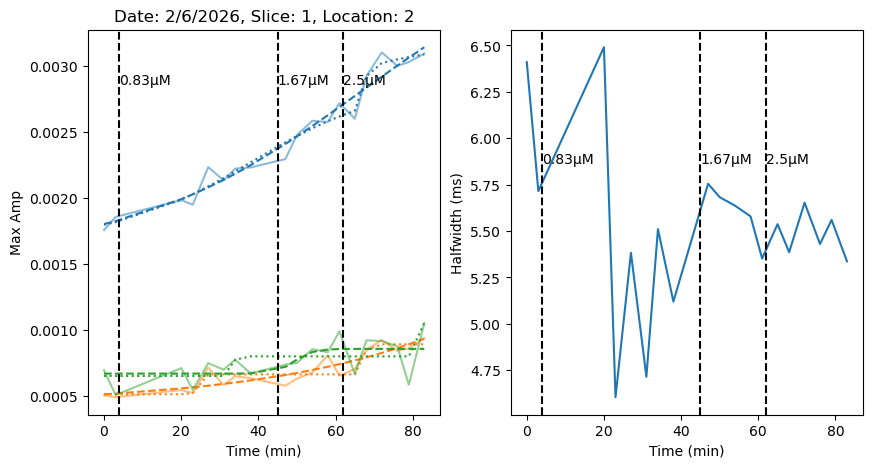

C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:8: RuntimeWarning: overflow encountered in exp
  return (A1 / (1 + np.exp(-k1 * (t - t1))) +


ROI 1: Logistic vs Double Logistic F-statistic = 6.190140820370276, p-value = 3.005524717991648e-10


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:51: MatplotlibDeprecationWarning: Adding an axes using t

ROI 2: Logistic vs Double Logistic F-statistic = -0.2691123333021383, p-value = 0.6060783800873442


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:172: MatplotlibDeprecationWarning: Adding an axes using 

ROI 3: Logistic vs Double Logistic F-statistic = 0.14032684985575547, p-value = 0.4442008755460991


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


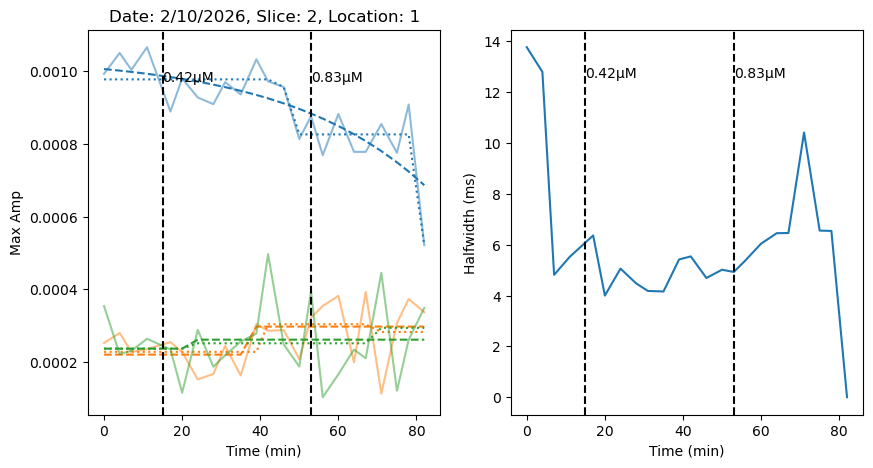

C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:5: RuntimeWarning: overflow encountered in exp
  return A / (1 + np.exp(-k * (t - t0))) + c
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:9: RuntimeWarning: overflow encountered in exp
  A2 / (1 + np.exp(-k2 * (t - t2))) + c)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:8: RuntimeWarning: overflow encountered in exp
  return (A1 / (1 + np.exp(-k1 * (t - t1))) +


ROI 1: Logistic vs Double Logistic F-statistic = 5.095773246598641, p-value = 1.7366032722954117e-07


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:51: MatplotlibDeprecationWarning: Adding an axes using t

ROI 2: Logistic vs Double Logistic F-statistic = 71.91138346549734, p-value = 0.0


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


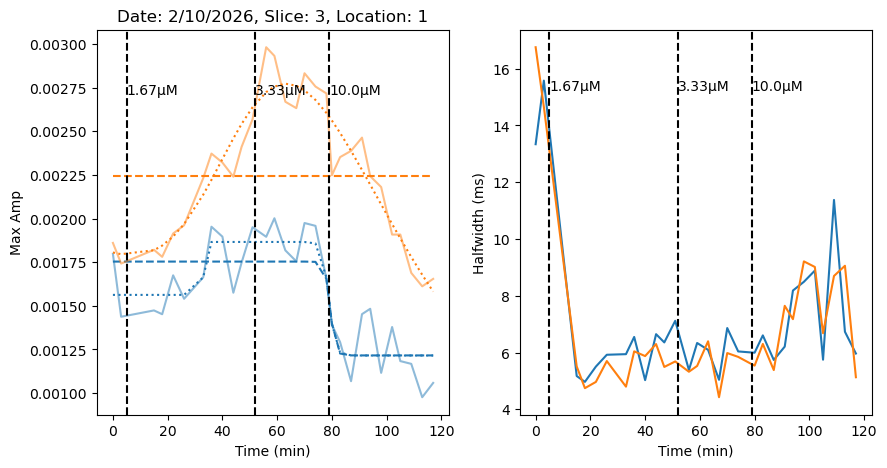

C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:5: RuntimeWarning: overflow encountered in exp
  return A / (1 + np.exp(-k * (t - t0))) + c
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:8: RuntimeWarning: overflow encountered in exp
  return (A1 / (1 + np.exp(-k1 * (t - t1))) +
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:9: RuntimeWarning: overflow encountered in exp
  A2 / (1 + np.exp(-k2 * (t - t2))) + c)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\scipy\optimize\minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

ROI 1: Logistic vs Double Logistic F-statistic = 0.08601485932732846, p-value = 0.4657273024847909


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\scipy\optimize\minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o

ROI 2: Logistic vs Double Logistic F-statistic = -0.8206819006042456, p-value = 0.7940862585335127
ROI 3: Logistic vs Double Logistic F-statistic = 1.8983195199573202, p-value = 0.028827002053624984


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:172: MatplotlibDeprecationWarning: Adding an axes using 

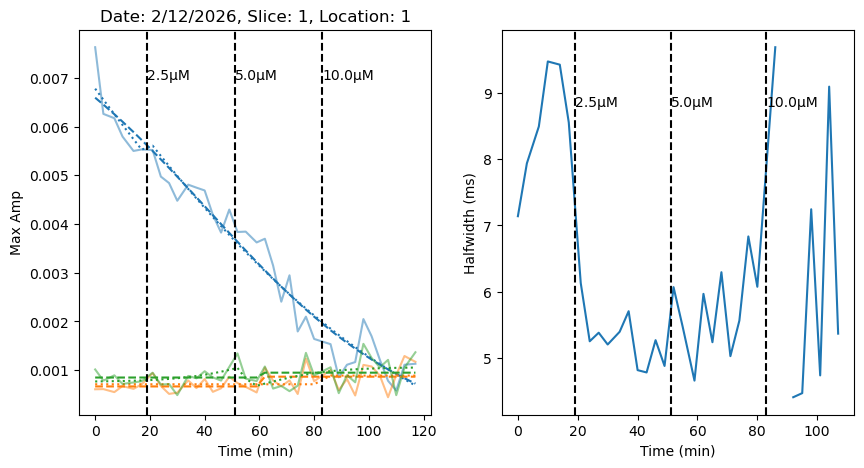

ROI 1: Logistic vs Double Logistic F-statistic = 3.9999386058235604, p-value = 3.167945923854276e-05


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:51: MatplotlibDeprecationWarning: Adding an axes using t

ROI 2: Logistic vs Double Logistic F-statistic = 8.5041099620865, p-value = 0.0


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:155: MatplotlibDeprecationWarning: Adding an axes using 

ROI 3: Logistic vs Double Logistic F-statistic = 0.7807887245158074, p-value = 0.217463383405456


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:172: MatplotlibDeprecationWarning: Adding an axes using 

ROI 4: Logistic vs Double Logistic F-statistic = 0.8085726314812443, p-value = 0.20938050625980575


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


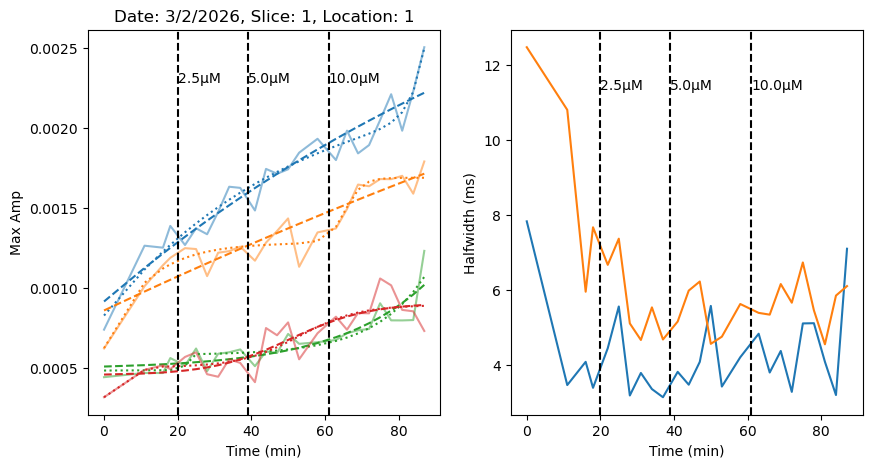

C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:9: RuntimeWarning: overflow encountered in exp
  A2 / (1 + np.exp(-k2 * (t - t2))) + c)


ROI 1: Logistic vs Double Logistic F-statistic = 0.32475374479927666, p-value = 0.37268372742659306


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:51: MatplotlibDeprecationWarning: Adding an axes using t

ROI 2: Logistic vs Double Logistic F-statistic = 3.1050469773215488, p-value = 0.0009512440298187208


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:51: MatplotlibDeprecationWarning: Adding an axes using t

Failed to fit curves for ROI 3


C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:51: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)


ROI 4: Logistic vs Double Logistic F-statistic = 0.4734871371522162, p-value = 0.31793283786093807


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:172: MatplotlibDeprecationWarning: Adding an axes using 

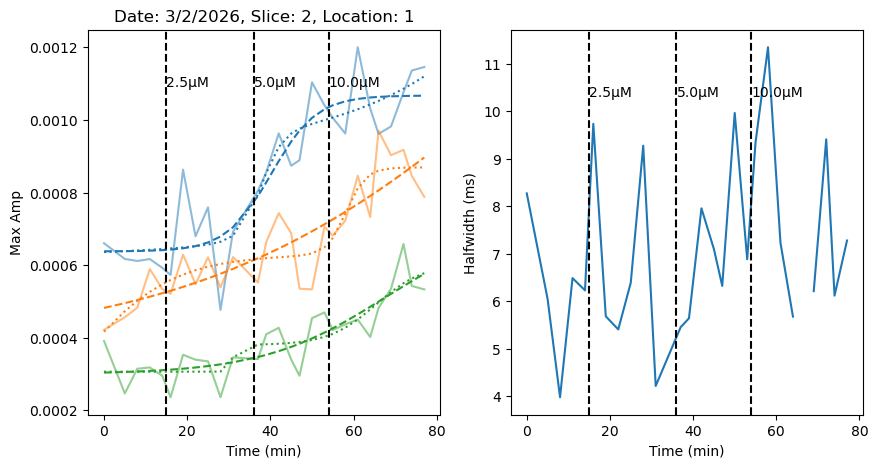

C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:9: RuntimeWarning: overflow encountered in exp
  A2 / (1 + np.exp(-k2 * (t - t2))) + c)


ROI 1: Logistic vs Double Logistic F-statistic = 1.9135494047951531, p-value = 0.027838877549641428


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:51: MatplotlibDeprecationWarning: Adding an axes using t

ROI 2: Logistic vs Double Logistic F-statistic = 2.4768249011406014, p-value = 0.006627845780249664


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:155: MatplotlibDeprecationWarning: Adding an axes using 

ROI 3: Logistic vs Double Logistic F-statistic = 0.7992675502299387, p-value = 0.21206764525356758


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


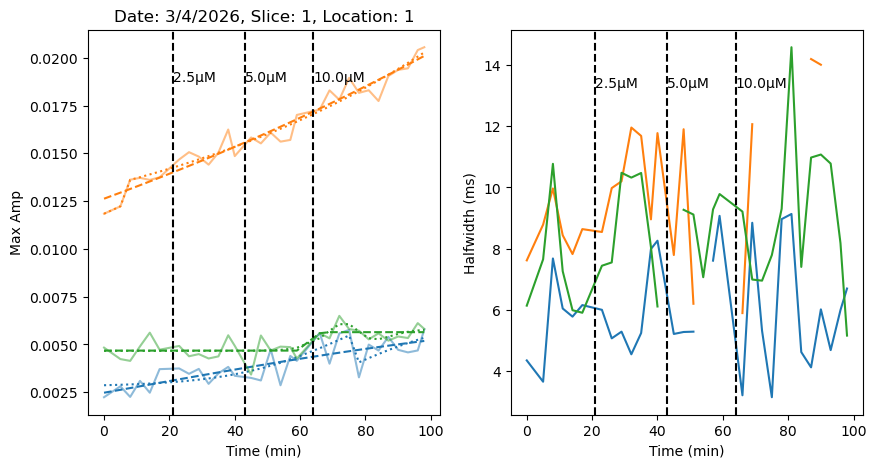

C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:5: RuntimeWarning: overflow encountered in exp
  return A / (1 + np.exp(-k * (t - t0))) + c
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:8: RuntimeWarning: overflow encountered in exp
  return (A1 / (1 + np.exp(-k1 * (t - t1))) +


ROI 1: Logistic vs Double Logistic F-statistic = 1.4158818063442118, p-value = 0.07840505629846584


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:51: MatplotlibDeprecationWarning: Adding an axes using t

ROI 2: Logistic vs Double Logistic F-statistic = 2.5318896724651294, p-value = 0.005672484070460171


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:155: MatplotlibDeprecationWarning: Adding an axes using 

ROI 3: Logistic vs Double Logistic F-statistic = 0.10671607250370511, p-value = 0.4575071157043583


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\1218626252.py:51: MatplotlibDeprecationWarning: Adding an axes using t

ROI 4: Logistic vs Double Logistic F-statistic = -0.4011370416565899, p-value = 0.655840384800343


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


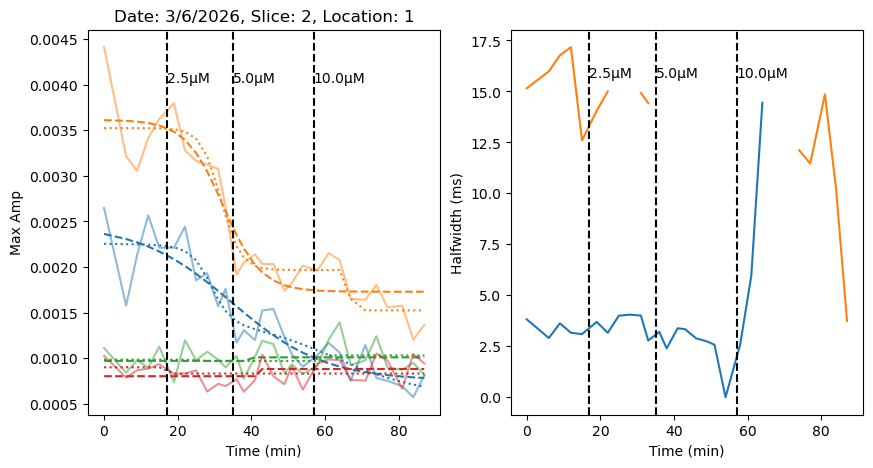

           total_curves total_significant total_failed_fits  \
increasing           17                 7                 1   
decreasing            6                 3                 0   
flat                  3                 1                 0   

           total_significant_with_non_monotonic_double_logistic  \
increasing                                                  2     
decreasing                                                  1     
flat                                                        1     

                                            logistic_rsquared  \
increasing  [0.962531845897164, 0.8176907219003259, 0.3795...   
decreasing  [0.6166647643069796, 0.6732913119870284, 0.952...   
flat        [0.012422808388812934, -2.582378755278114e-13,...   

                                     double_logistic_rsquared  \
increasing  [0.9774385865809949, 0.8648022227760994, 0.452...   
decreasing  [0.8225834880094998, 0.8037392046409567, 0.952...   
flat        [0.0377410

In [7]:
# plot the trace for each ROI 
fraction_rois_to_plot = 1.0  # 0.05  # for visual clarity, only plot a random subset of the ROIs

def logistic(t, A, k, t0, c):
    return A / (1 + np.exp(-k * (t - t0))) + c

def double_logistic(t, A1, k1, t1, A2, k2, t2, c):
    return (A1 / (1 + np.exp(-k1 * (t - t1))) +
            A2 / (1 + np.exp(-k2 * (t - t2))) + c)

curve_count = {'increasing': {'total_curves': 0, 'total_significant': 0, 'total_failed_fits': 0, 'total_significant_with_non_monotonic_double_logistic': 0,
                              'logistic_rsquared': [], 'double_logistic_rsquared': [], 'logistic_aic': [], 'double_logistic_aic': [], 'p_values': []},
               'decreasing': {'total_curves': 0, 'total_significant': 0, 'total_failed_fits': 0, 'total_significant_with_non_monotonic_double_logistic': 0,
                              'logistic_rsquared': [], 'double_logistic_rsquared': [], 'logistic_aic': [], 'double_logistic_aic': [], 'p_values': []},
               'flat': {'total_curves': 0, 'total_significant': 0, 'total_failed_fits': 0, 'total_significant_with_non_monotonic_double_logistic': 0,
                        'logistic_rsquared': [], 'double_logistic_rsquared': [], 'logistic_aic': [], 'double_logistic_aic': [], 'p_values': []}}

for df in dfs:
    for date in df['Date'].unique():
        date_df = df[df['Date'] == date]
        for slic in date_df['Slice'].unique():
            slice_df = date_df[date_df['Slice'] == slic]
            stim_layer = slice_df['Stim_Layer'].values[0]
            for location in slice_df['Location'].unique():

                plt.subplots(1, 2, figsize=(10, 5))
                location_df = slice_df[slice_df['Location'] == location]
                for roi in location_df['ROI'].unique():
                    roi_df = location_df[location_df['ROI'] == roi]
                    # ROI Set value
                    roi_set = roi_df['ROI_Set'].values[0]

                    times = np.array(roi_df['time'].values)
                    # convert times to time datatype to allow subtraction
                    times = pd.to_datetime(times)
                    init_time = times[0]
                    times = times - init_time  # convert to minutes relative to start of recording
                    times = times.total_seconds() / 60  # convert to minutes

                    should_plot_this_roi = random.random() < fraction_rois_to_plot  # randomly select a fraction of the ROIs to plot for visual clarity

                    # classify curve as increasing, decreasing, or flat based on whether the max_amp at the last time point is greater than the max_amp at the first time point, with a threshold for noise
                    if roi_df['amp'].iloc[-1] > roi_df['amp'].iloc[0] * 1.2:  # if the last max_amp is greater than the first max_amp by at least 20%, classify as increasing
                        curve_type = 'increasing'
                    elif roi_df['amp'].iloc[-1] < roi_df['amp'].iloc[0] * 0.8:  # if the last max_amp is less than the first max_amp by at least 20%, classify as decreasing
                        curve_type = 'decreasing'
                    else:
                        curve_type = 'flat'
                    curve_count[curve_type]['total_curves'] += 1

                    plt.subplot(1, 2, 1)
                    plt.xlabel('Time (min)')
                    plt.ylabel('Max Amp')
                    plt.title(f"Date: {date}, Slice: {slic}, Location: {location}")

                    # perform isotonic regression on the max_amp, as a significance test for whether 
                    # there is significant non-monotonicity in the dose-response relationship
                    #ir = IsotonicRegression(increasing='auto')
                    #y_ir = ir.fit_transform(times, roi_df['amp'])
                    # plot the isotonic regression result as a dashed line
                    #if should_plot_this_roi:
                    #    plt.plot(times, y_ir, linestyle='--', color=plt.gca().lines[-1].get_color())

                    # baseline fit: 4-degree polynomial fit to see if there is a significant improvement in fit compared to isotonic regression, which would suggest a non-monotonic relationship
                    #poly = np.polyfit(times, roi_df['amp'], 4)
                    #y_poly = np.polyval(poly, times)
                    ## plot the baseline fit as a solid line
                    #plt.plot(times, y_poly, linestyle='-', color=plt.gca().lines[-1].get_color())

                    # baseline fit: spline fit to see if there is a significant improvement in fit compared to isotonic regression, which would suggest a non-monotonic relationship
                    #spline = UnivariateSpline(times, roi_df['amp'], k=5, s=0.5)  # k is the degree of the spline, s is the smoothing factor (s=0 => InterpolatedUnivariateSpline)
                    #y_spline = spline(times)
                    #if should_plot_this_roi:
                    #    plt.plot(times, y_spline, linestyle='dotted', color=plt.gca().lines[-1].get_color())

                    # compare the isotonic regression fit to the spline fit using an F-test to see if the 
                    # spline fit is significantly better, which would suggest a non-monotonic relationship
                    #rss_ir = np.sum((roi_df['amp'] - y_ir) ** 2)
                    #rss_spline = np.sum((roi_df['amp'] - y_spline) ** 2)
                    #df_ir = len(times) - 1  # degrees of freedom for isotonic regression
                    #df_spline = len(times) - 6  # degrees of freedom for spline (6 parameters for 5-degree spline)
                    #f_stat = ((rss_ir - rss_spline) / (df_ir - df_spline)) / (rss_spline / df_spline)
                    #p_value = 1 - norm.cdf(f_stat)
                    #print(f"ROI {roi}: F-statistic = {f_stat}, p-value = {p_value}")

                    # annotate significant non-monotonicity if p < 0.05
                    #if p_value < 0.05 and should_plot_this_roi:
                    #    sci_notation_p = "{:.2e}".format(p_value)
                    #    plt.text(times[len(times)//4], max(roi_df['amp']), f'Non-monotonic (p = {sci_notation_p})', color=plt.gca().lines[-1].get_color(), fontsize=12, ha='center')

                    # fit and compare logistic vs double logistic
                    p0_logistic = [max(roi_df['amp']), 1, np.median(times), min(roi_df['amp'])]  # initial guess for logistic parameters
                    p0_double_logistic = [max(roi_df['amp'])/2, 1, np.median(times)/2, max(roi_df['amp'])/2, 1, np.median(times)*1.5, min(roi_df['amp'])]  # initial guess for double logistic parameters
                    try:
                        p1, _ = curve_fit(logistic, times, roi_df['amp'], p0=p0_logistic, maxfev=10000)
                        p2, _ = curve_fit(double_logistic, times, roi_df['amp'], p0=p0_double_logistic, maxfev=20000)
                    except:
                        print(f"Failed to fit curves for ROI {roi}")
                        curve_count[curve_type]['total_failed_fits'] += 1
                        continue

                    y_logistic = logistic(times, *p1)
                    y_double_logistic = double_logistic(times, *p2)
                    rss_logistic = np.sum((roi_df['amp'] - y_logistic) ** 2)
                    rss_double_logistic = np.sum((roi_df['amp'] - y_double_logistic) ** 2)

                    # rsquared for logistic and double logistic
                    ss_total = np.sum((roi_df['amp'] - np.mean(roi_df['amp'])) ** 2)
                    r_squared_logistic = 1 - (rss_logistic / ss_total)
                    r_squared_double_logistic = 1 - (rss_double_logistic / ss_total)
                    curve_count[curve_type]['logistic_rsquared'].append(r_squared_logistic)
                    curve_count[curve_type]['double_logistic_rsquared'].append(r_squared_double_logistic)

                    # AIC for logistic and double logistic
                    aic_logistic = 2 * 4 + len(times) * np.log(rss_logistic / len(times))
                    aic_double_logistic = 2 * 7 + len(times) * np.log(rss_double_logistic / len(times))
                    curve_count[curve_type]['logistic_aic'].append(aic_logistic)
                    curve_count[curve_type]['double_logistic_aic'].append(aic_double_logistic)
                    

                    df_logistic = len(times) - 4  # degrees of freedom for logistic (4 parameters)
                    df_double_logistic = len(times) - 7  # degrees of freedom for double logistic (7 parameters)
                    f_stat = ((rss_logistic - rss_double_logistic) / (df_logistic - df_double_logistic)) / (rss_double_logistic / df_double_logistic)
                    p_value = 1 - norm.cdf(f_stat)
                    print(f"ROI {roi}: Logistic vs Double Logistic F-statistic = {f_stat}, p-value = {p_value}")
                    curve_count[curve_type]['p_values'].append(p_value)
                    if p_value < 0.05:
                        curve_count[curve_type]['total_significant'] += 1
                        
                        # if the double logistic is significantly better than the single logistic, mark whether the 
                        # double logistic fit is non-monotonic (i.e. has slopes of both signs)
                        
                        # calculate the different series and call it the slope (A(x+1) - A(x))
                        double_logistic_slope = np.diff(y_double_logistic) / np.diff(times)
                        if np.any(double_logistic_slope > 0) and np.any(double_logistic_slope < 0):
                            curve_count[curve_type]['total_significant_with_non_monotonic_double_logistic'] += 1
                            should_plot_this_roi = True

                    if should_plot_this_roi:
                        plt.plot(times, roi_df['amp'], label=f"ROI {roi}", alpha=0.5)
                    if should_plot_this_roi:
                        plt.plot(times, y_logistic, linestyle='--', color=plt.gca().lines[-1].get_color(), label=f'Logistic Fit ROI {roi}')
                        plt.plot(times, y_double_logistic, linestyle=':', color=plt.gca().lines[-1].get_color(), label=f'Double Logistic Fit ROI {roi}')
                    if p_value < 0.05:
                        if should_plot_this_roi:
                            sci_notation_p = "{:.2e}".format(p_value)
                            #plt.text(times[len(times)//4], max(roi_df['amp'])*0.9, f'Multi-logistic (p = {sci_notation_p})', color=plt.gca().lines[-1].get_color(), fontsize=12, ha='center')

                    # filter halfwidths > 20
                    roi_df.loc[roi_df['halfwidth'] > 20] = np.nan
                    # stricter halfwidth filter for low-amplitude (late / high NBQX) responses
                    roi_df.loc[(roi_df['NBQX_conc'] > 2) & (roi_df['halfwidth'] > 15)] = np.nan
                    # in subplot 2, plot halfwidth vs time
                    if roi == 1 or np.mean(roi_df['amp']) > 0.001:  # only plot halfwidth for ROI 1 or if mean amp is above threshold
                        plt.subplot(1, 2, 2)
                        plt.plot(times, roi_df['halfwidth'])
                        plt.xlabel('Time (min)')
                        plt.ylabel('Halfwidth (ms)')

                # nbqx times table to mark when each new concentration of NBQX was infused
                nbqx_times = roi_df[['NBQX_conc', 'infusion_time']].drop_duplicates()
                nbqx_conc = nbqx_times['NBQX_conc'].values
                nbqx_times = nbqx_times['infusion_time'].values
                nbqx_times = pd.to_datetime(np.array(nbqx_times))
                nbqx_times -= init_time
                nbqx_times = nbqx_times.total_seconds() / 60  # convert to minutes
                
                # mark nbqx infusion times on the plots
                for i in range(len(nbqx_times)):
                    # as vertical lines with text indicating the concentration
                    for j in range(1, 3):
                        plt.subplot(1, 2, j)
                        plt.axvline(x=nbqx_times[i], color='black', linestyle='--')
                        plt.text(nbqx_times[i], plt.ylim()[1]*0.9, f"{nbqx_conc[i]}μM", 
                                color='black', va='top', ha='left')
                plt.subplot(1, 2, 1)
                #plt.legend()
                plt.savefig(os.path.join(output_fig_dir, f"{roi_selection}_{date.replace('/', '_')}_slice{slic}_location{location}_dose-response_{stim_layer.replace('/', '_')}.png"))
                
                plt.show()

curve_count_df = pd.DataFrame(curve_count).T
curve_count_df['percent_significant'] = curve_count_df['total_significant'] / curve_count_df['total_curves'] * 100
curve_count_df['percent_failed_fits'] = curve_count_df['total_failed_fits'] / curve_count_df['total_curves']
print(curve_count_df)

Increasing Curves: Logistic vs Double Logistic rsquared t-statistic = -0.3743273176514524, p-value = 0.7107938764140055
Decreasing Curves: Logistic vs Double Logistic rsquared t-statistic = -0.3439780909902619, p-value = 0.7379887270977683
Flat Curves: Logistic vs Double Logistic rsquared t-statistic = -1.0081314669035077, p-value = 0.41775055786896104
All Curves: Logistic vs Double Logistic rsquared t-statistic = -0.7901622372431848, p-value = 0.43332065374927153


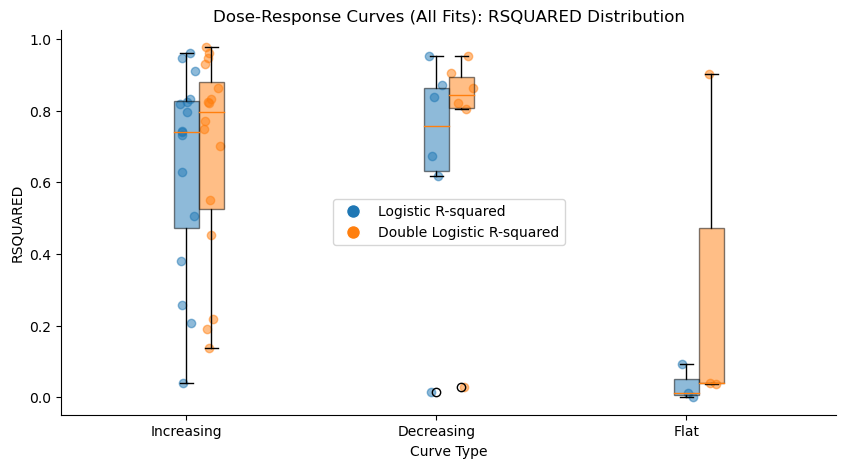

Increasing Curves: Logistic vs Double Logistic rsquared t-statistic = -0.4122299678331431, p-value = 0.6875845059849282
Decreasing Curves: Logistic vs Double Logistic rsquared t-statistic = -1.4754031265239693, p-value = 0.2488095611356591
Flat Curves: Logistic vs Double Logistic rsquared t-statistic = nan, p-value = nan
All Curves: Logistic vs Double Logistic rsquared t-statistic = -0.7901622372431848, p-value = 0.43332065374927153


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\fromnumeric.py:3702: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:253: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


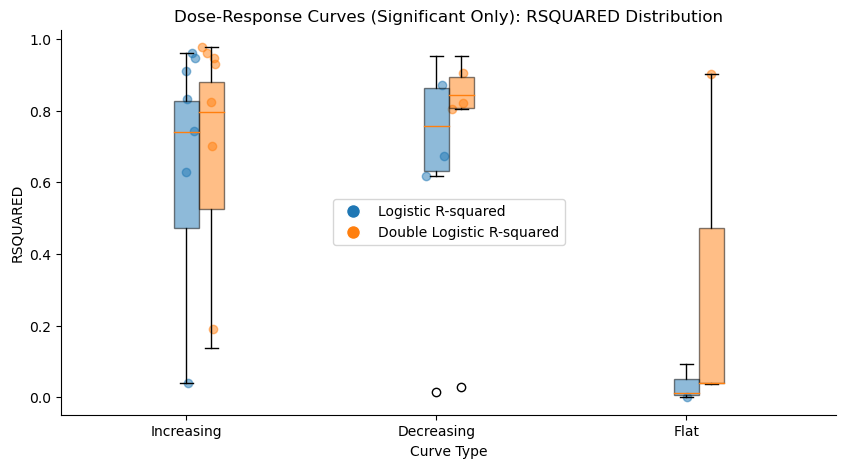

Increasing Curves: Logistic vs Double Logistic aic t-statistic = -0.008478597815862568, p-value = 0.9932912846324679
Decreasing Curves: Logistic vs Double Logistic aic t-statistic = 0.07258462690190291, p-value = 0.9435800993906575
Flat Curves: Logistic vs Double Logistic aic t-statistic = 0.37912541042189357, p-value = 0.7248428305166615
All Curves: Logistic vs Double Logistic aic t-statistic = 0.12178837520904748, p-value = 0.9035750882562139


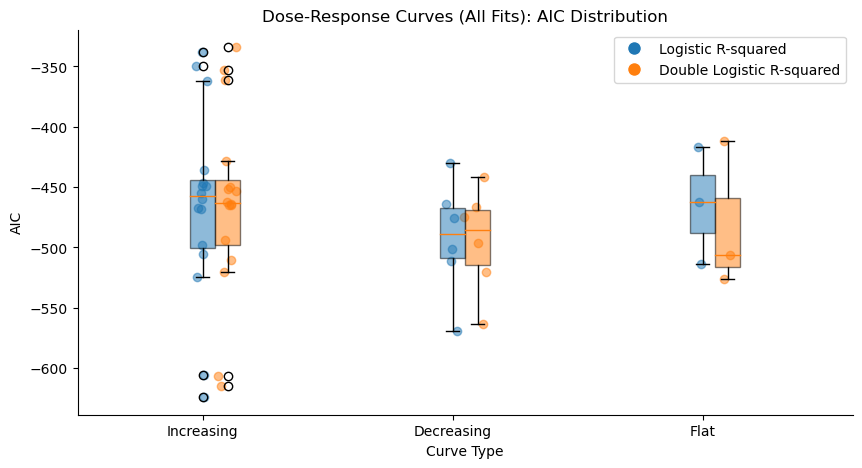

Increasing Curves: Logistic vs Double Logistic aic t-statistic = 0.11953687960056313, p-value = 0.9068284347745075
Decreasing Curves: Logistic vs Double Logistic aic t-statistic = 0.23718182222672138, p-value = 0.8241699365193351
Flat Curves: Logistic vs Double Logistic aic t-statistic = nan, p-value = nan
All Curves: Logistic vs Double Logistic aic t-statistic = 0.12178837520904748, p-value = 0.9035750882562139


c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\fromnumeric.py:3702: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\numpy\core\_methods.py:253: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


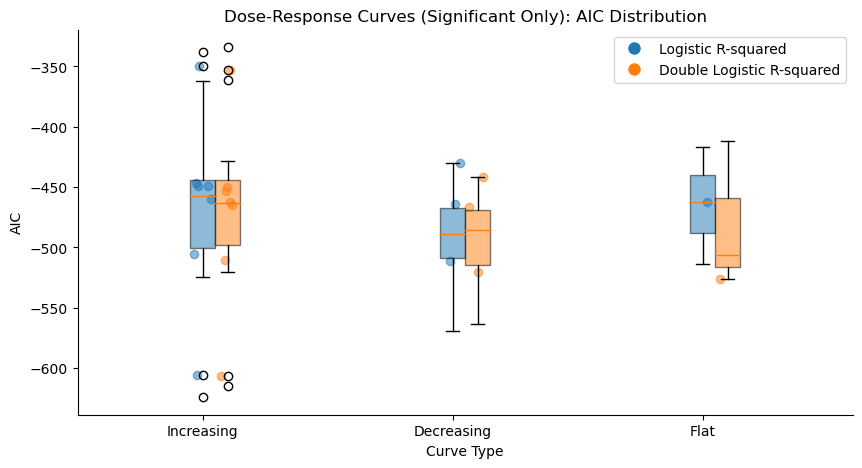

In [8]:
# plot 1-D scatters of logistic and double logistic rsquared values for each curve type
for fitting_metric in ['rsquared', 'aic']:
    for significant_only in [False, True]:  # True, False
        plt.figure(figsize=(10, 5))
        for i_c, curve_type in enumerate(curve_count):
            if not significant_only:
                if fitting_metric == 'rsquared':
                    x_jitter_logistic = np.random.normal(0, 0.02, size=len(curve_count[curve_type]['logistic_rsquared']))
                    x_jitter_double_logistic = np.random.normal(0.1, 0.02, size=len(curve_count[curve_type]['double_logistic_rsquared']))
                    plt.scatter(x_jitter_logistic + i_c, curve_count[curve_type]['logistic_rsquared'], alpha=0.5, label=f'{curve_type.capitalize()} Logistic R-squared', color='tab:blue')
                    plt.scatter(x_jitter_double_logistic + i_c, curve_count[curve_type]['double_logistic_rsquared'], alpha=0.5, label=f'{curve_type.capitalize()} Double Logistic R-squared', color='tab:orange')
                elif fitting_metric == 'aic':
                    x_jitter_logistic = np.random.normal(0, 0.02, size=len(curve_count[curve_type]['logistic_aic']))
                    x_jitter_double_logistic = np.random.normal(0.1, 0.02, size=len(curve_count[curve_type]['double_logistic_aic']))
                    plt.scatter(x_jitter_logistic + i_c, curve_count[curve_type]['logistic_aic'], alpha=0.5, label=f'{curve_type.capitalize()} Logistic AIC', color='tab:blue')
                    plt.scatter(x_jitter_double_logistic + i_c, curve_count[curve_type]['double_logistic_aic'], alpha=0.5, label=f'{curve_type.capitalize()} Double Logistic AIC', color='tab:orange')
            else:  # filter to only include rsquared or aic for p-values < 0.05
                if fitting_metric == 'rsquared':
                    filtered_logistic_rsquared = [r for r, p in zip(curve_count[curve_type]['logistic_rsquared'], curve_count[curve_type]['p_values']) if p < 0.05]
                    filtered_double_logistic_rsquared = [r for r, p in zip(curve_count[curve_type]['double_logistic_rsquared'], curve_count[curve_type]['p_values']) if p < 0.05]
                    x_jitter_logistic = np.random.normal(0, 0.02, size=len(filtered_logistic_rsquared))
                    x_jitter_double_logistic = np.random.normal(0.1, 0.02, size=len(filtered_double_logistic_rsquared))
                    plt.scatter(x_jitter_logistic + i_c, filtered_logistic_rsquared, alpha=0.5, label=f'{curve_type.capitalize()} Logistic R-squared (p < 0.05)', color='tab:blue')
                    plt.scatter(x_jitter_double_logistic + i_c, filtered_double_logistic_rsquared, alpha=0.5, label=f'{curve_type.capitalize()} Double Logistic R-squared (p < 0.05)', color='tab:orange')
                elif fitting_metric == 'aic':
                    filtered_logistic_aic = [a for a, p in zip(curve_count[curve_type]['logistic_aic'], curve_count[curve_type]['p_values']) if p < 0.05]
                    filtered_double_logistic_aic = [a for a, p in zip(curve_count[curve_type]['double_logistic_aic'], curve_count[curve_type]['p_values']) if p < 0.05]
                    x_jitter_logistic = np.random.normal(0, 0.02, size=len(filtered_logistic_aic))
                    x_jitter_double_logistic = np.random.normal(0.1, 0.02, size=len(filtered_double_logistic_aic))
                    plt.scatter(x_jitter_logistic + i_c, filtered_logistic_aic, alpha=0.5, label=f'{curve_type.capitalize()} Logistic AIC (p < 0.05)', color='tab:blue')
                    plt.scatter(x_jitter_double_logistic + i_c, filtered_double_logistic_aic, alpha=0.5, label=f'{curve_type.capitalize()} Double Logistic AIC (p < 0.05)', color='tab:orange')
        plt.ylabel(f'{fitting_metric.upper()}')
        plt.title(f'Dose-Response Curves ({"Significant Only" if significant_only else "All Fits"}): {fitting_metric.upper()} Distribution')
        plt.legend(handles=[
            plt.Line2D([0], [0], marker='o', color='w', label='Logistic R-squared', markerfacecolor='tab:blue', markersize=10),
            plt.Line2D([0], [0], marker='o', color='w', label='Double Logistic R-squared', markerfacecolor='tab:orange', markersize=10)
        ])
        # add box plots
        for i_c, curve_type in enumerate(curve_count):
            plt.boxplot(curve_count[curve_type][f'logistic_{fitting_metric}'], positions=[i_c], widths=0.1, patch_artist=True, boxprops=dict(facecolor='tab:blue', alpha=0.5))
            plt.boxplot(curve_count[curve_type][f'double_logistic_{fitting_metric}'], positions=[i_c + 0.1], widths=0.1, patch_artist=True, boxprops=dict(facecolor='tab:orange', alpha=0.5))
        plt.xticks([0, 1, 2], ['Increasing', 'Decreasing', 'Flat'])
        plt.xlabel("Curve Type")

        # compare for significance using t-test
        for i_c, curve_type in enumerate(curve_count):
            logistic_rsquared = curve_count[curve_type][f'logistic_{fitting_metric}']
            double_logistic_rsquared = curve_count[curve_type][f'double_logistic_{fitting_metric}']
            if significant_only:
                logistic_rsquared = [r for r, p in zip(logistic_rsquared, curve_count[curve_type]['p_values']) if p < 0.05]
                double_logistic_rsquared = [r for r, p in zip(double_logistic_rsquared, curve_count[curve_type]['p_values']) if p < 0.05]
            t_stat, p_value = ttest_ind(logistic_rsquared, double_logistic_rsquared, equal_var=False)
            print(f"{curve_type.capitalize()} Curves: Logistic vs Double Logistic {fitting_metric} t-statistic = {t_stat}, p-value = {p_value}")
            # annotate significance on the plot
            if p_value < 0.05:
                plt.text(i_c, 0.95, f'p = {p_value:.3f}', fontsize=20, ha='center')
        # significance if all three groups are lumped together
        all_logistic_rsquared = []
        all_double_logistic_rsquared = []
        for curve_type in curve_count:
            all_logistic_rsquared += curve_count[curve_type][f'logistic_{fitting_metric}']
            all_double_logistic_rsquared += curve_count[curve_type][f'double_logistic_{fitting_metric}']
        t_stat, p_value = ttest_ind(all_logistic_rsquared, all_double_logistic_rsquared, equal_var=False)
        print(f"All Curves: Logistic vs Double Logistic {fitting_metric} t-statistic = {t_stat}, p-value = {p_value}")

        # turn off spines
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.savefig(os.path.join(output_fig_dir, f"{roi_selection}_dose-response_curve_comparison_{fitting_metric}{'_significant_only' if significant_only else '_all_fits'}.png"))
        plt.show()

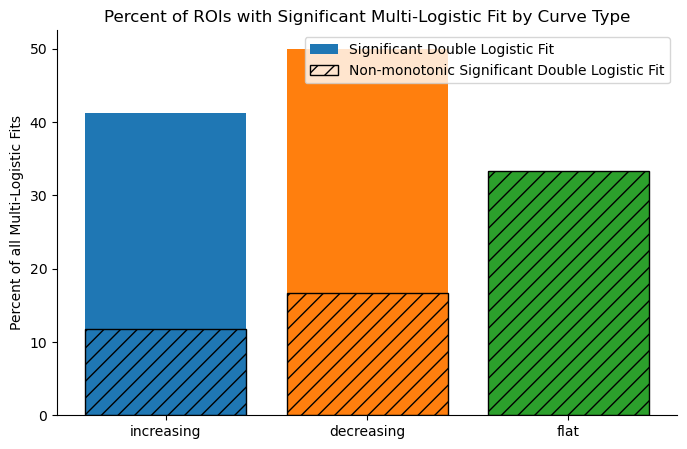

In [9]:
# use curve_count to show breakdown of significant multi-logistic fits vs curve type, and distribution of fitting metrics for each curve type, 
# to see if there is a relationship between curve type and likelihood of having a significant multi-logistic fit or better fit with double 
# logistic compared to single logistic, which would suggest a more complex dose-response relationship for certain curve types 
# (e.g. non-monotonic curves may be more likely to have significant multi-logistic fits)
# bar plot of percent significant multi-logistic fits for each curve type
plt.figure(figsize=(8, 5))
plt.bar(curve_count_df.index, curve_count_df['percent_significant'], color=['tab:blue', 'tab:orange', 'tab:green'], label='Significant Double Logistic Fit')

# hatched bars to indicate the percent of significant multi-logistic fits that had a non-monotonic double logistic fit, 
# as a way to visualize how many of the significant multi-logistic fits were likely driven by non-monotonicity in the dose-response relationship
for i, curve_type in enumerate(curve_count_df.index):
    percent_non_monotonic = curve_count_df.loc[curve_type, 'total_significant_with_non_monotonic_double_logistic'] / curve_count_df.loc[curve_type, 'total_curves'] * 100 if curve_count_df.loc[curve_type, 'total_significant'] > 0 else 0
    plt.bar(i, percent_non_monotonic, color='none', edgecolor='black', hatch='//', label='Non-monotonic Significant Double Logistic Fit' if i == 0 else "")

# remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.ylabel('Percent of all Multi-Logistic Fits')
plt.title('Percent of ROIs with Significant Multi-Logistic Fit by Curve Type')
plt.savefig(os.path.join(output_fig_dir, f"{roi_selection}_percent_significant_multi_logistic_fits_by_curve_type.png"))
plt.show()

In [10]:
# compute the delta of the amplitude for each pixel at each time-step.
# then create a heatmap of the delta amplitude for each pixel at each time-step, to visualize how the spatial pattern of responses changes over time with NBQX infusion
# only do for pixels in the 9-px ROIs, leaving all other pixels blank

for date in nine_px_df['Date'].unique():
    date_df = nine_px_df[nine_px_df['Date'] == date]
    for slic in date_df['Slice'].unique():
        slice_df = date_df[date_df['Slice'] == slic]
        stim_layer = slice_df['Stim_Layer'].values[0]
        for location in slice_df['Location'].unique():
            location_df = slice_df[slice_df['Location'] == location]
            num_times = len(location_df['time'].unique())
            delta_amp_image = np.zeros((80, 80, num_times), dtype=np.float32)
            delta_amp_image[:] = np.nan  # initialize all values to NaN so that they will be white in the heatmap, and only pixels with data will be colored
            
            barrel_traces = {}
            for roi_set in location_df['ROI_Set'].unique():
                roi_set_df = location_df[location_df['ROI_Set'] == roi_set]
                roi_set = roi_set_df['ROI_Set'].values[0]
                if 'output__masked_grid' not in roi_set:
                    continue
                barrel_traces[roi_set] = {'mean': [], 'sem': []}
                date_corrected = date.split('/')[0].zfill(2) + '-' + date.split('/')[1].zfill(2) + '-' + date.split('/')[2][2:]
                roi_file_path = os.path.join(data_dir + ("L23/" if '03' in date_corrected else ""), f"{date_corrected}/converted_zda/{roi_set}.dat")
                print(roi_file_path)

                print(roi_set_df.columns)

                # load the RLI image for this recording by looking it up in barrels_df to get the date, slice, and location, and then constructing the file path
                rli_row = barrels_df[(barrels_df['Date'] == date) &
                                    (barrels_df['Slice'] == slic) &
                                        (barrels_df['Location'] == location)]
                if len(rli_row) == 0:
                    print(f"No RLI image found for {date}, {slic}, {location}")
                    continue
                #rli_file_path = rli_row['RLI_File'].values[0]
                #rli_image = read_array_file(rli_file_path)

                # create a figure with the RLI image as the background
                #plt.figure(figsize=(8, 8))
                #plt.imshow(rli_image, cmap='gray')
                #plt.title(f"Date: {date}, Slice: {slic}, Location: {location} - Delta Amplitude Heatmap")

                # loop through each time point and create a heatmap of the delta amplitude for each pixel
                times = np.array(roi_set_df['time'].values)
                times = pd.to_datetime(times)
                init_time = times[0]
                times = times - init_time  # convert to minutes relative to start of recording
                times = times.total_seconds() / 60  # convert to minutes

                for t in sorted(roi_set_df['time'].unique()):
                    time_df = roi_set_df[roi_set_df['time'] == t]
                    t_idx = list(roi_set_df['time'].unique()).index(t)

                    trace_point_mean = []
                    for index, row in time_df.iterrows():
                        roi_number = row['ROI']
                        amp = row['amp']
                        # get the pixel coordinates for this ROI from the ROI file

                        # convert date d/m/yyyy to dd-mm-yy to construct the file path for the ROI file
                        
                        roi_reader = ROIFileReader(roi_file_path)
                        roi_coords = roi_reader.get_roi_list()  # list of (x, y) tuples

                        # calculate the delta amplitude for this ROI compared to the first time point (baseline)
                        baseline_amp = roi_set_df[(roi_set_df['ROI'] == roi_number) & (roi_set_df['time'] == roi_set_df['time'].min())]['amp'].values[0]
                        delta_amp = (amp - baseline_amp) * 1000
                        trace_point_mean.append(delta_amp)

                        #print(f"Time: {t}, ROI: {roi_number}, Delta Amp: {delta_amp}", "roi len:", len(roi_coords))

                        # update the delta amplitude image for this ROI
                        for (x, y) in roi_coords[roi_number-1]:  # roi_number is 1-indexed, but roi_coords is 0-indexed
                            if 0 <= x < delta_amp_image.shape[1] and 0 <= y < delta_amp_image.shape[0]:
                                delta_amp_image[y, x, t_idx] = delta_amp
                    
                    # update the barrel_traces dict with the mean delta amplitude for this barrel at this time point, to use for plotting the traces later
                    barrel_traces[roi_set]['mean'].append(np.nanmean(trace_point_mean))
                    barrel_traces[roi_set]['sem'].append(np.nanstd(trace_point_mean) / np.sqrt(len(trace_point_mean)))

            # determine vmin and vmax for the heatmap based on the 5th and 95th percentiles of the delta amplitude values, to avoid outliers dominating the color scale
            vmin = np.nanpercentile(delta_amp_image, 5)
            vmax = np.nanpercentile(delta_amp_image, 95)

            # center the colorscale at 0
            vmin = min(vmin, -vmax)
            vmax = max(vmax, -vmin)

            times = sorted(roi_set_df['time'].unique())
            times = pd.to_datetime(times)
            init_time = times[0]
            times = times - init_time  # convert to minutes relative to start of recording
            times = times.total_seconds() / 60  # convert to minutes

            image_file_list = []
            for t in sorted(roi_set_df['time'].unique()):
                # convert t from timestampe (e.g. 1:00) to minutes relative to start of recording for the title and file name
                t_converted = pd.to_datetime(t) - init_time
                t_converted = t_converted.total_seconds() / 60  # convert to minutes
                t_idx = list(roi_set_df['time'].unique()).index(t)
                plt.subplots(1, 2, figsize=(12, 6))
                plt.subplot(1, 2, 1)
                # colorscale is blue-white-red, with white at 0, blue for negative delta amplitude, and red for positive delta amplitude
                plt.imshow(delta_amp_image[:, :, t_idx], cmap='RdBu_r', vmin=vmin, vmax=vmax)
                # make background black for pixels with NaN values (i.e. pixels that are not in any ROI)
                plt.gca().set_facecolor('black')
                plt.title(f"t = {t_converted:.1f} min, {roi_set_df[roi_set_df['time'] == t]['NBQX_conc'].values[0]} μM NBQX")
                plt.colorbar(label='Delta Amplitude')
                output_image_path = os.path.join(output_fig_dir, f"{roi_selection}_{date.replace('/', '_')}_slice{slic}_location{location}_delta_amp_heatmap_time{str(t_converted)}min.png")

                # in the right subplot, plot the mean amplitude of each barrel up to this time point (as scatter with error bars for SEM), to show how the overall response is 
                # changing over time with NBQX infusion, and how that relates to the spatial pattern of responses in the heatmap on the left
                plt.subplot(1, 2, 2)
                for barrel in barrel_traces:
                    trace = barrel_traces[barrel]['mean']
                    sem = barrel_traces[barrel]['sem']
                     
                    # trace color is whatever color of the RdBu_r colormap corresponds to the mean delta amplitude for this barrel at this time point, to visually link the trace to the heatmap
                    trace_color = 'purple' # #plt.cm.RdBu_r((trace[t_idx] - vmin) / (vmax - vmin))

                    # scatter plot with errorbars for SEM
                    print(times[:t_idx+1], trace[:t_idx+1], sem[:t_idx+1])
                    plt.errorbar(times[:t_idx+1], trace[:t_idx+1], yerr=sem[:t_idx+1], label=barrel, color=trace_color)
            
                plt.xlabel('Time (min)')
                plt.ylabel('Mean Amp')
                plt.ylim(np.nanmin([np.nanmin(barrel_traces[barrel]['mean']) for barrel in barrel_traces]), 
                         np.nanmax([np.nanmax(barrel_traces[barrel]['mean']) for barrel in barrel_traces]))
                # set y ticks off
                plt.yticks([])
                plt.xticks([15, 30, 45, 60, 75, 90], [15, 30, 45, 60, 75, 90])

                # vertical lines to indicate NBQX infusion times
                nbqx_times = roi_set_df[['NBQX_conc', 'infusion_time']].drop_duplicates()
                nbqx_conc = nbqx_times['NBQX_conc'].values
                nbqx_times = nbqx_times['infusion_time'].values
                nbqx_times = pd.to_datetime(np.array(nbqx_times))
                # remove nan
                nbqx_times = nbqx_times[~pd.isna(nbqx_times)]
                nbqx_times -= init_time
                nbqx_times = nbqx_times.total_seconds() / 60  # convert to minutes
                # remove 0 from nbqx_conc and corresponding concentration from nbqx_times, since that is the baseline
                for nbc in nbqx_conc:
                    if nbc == 0:
                        idx = np.where(nbqx_conc == nbc)[0][0]
                        nbqx_conc = np.delete(nbqx_conc, idx)
                        break

                for i in range(len(nbqx_times)):
                    plt.axvline(x=nbqx_times[i], color='black', linestyle='--')
                    plt.text(nbqx_times[i], plt.ylim()[1]*0.9, f"{nbqx_conc[i]}μM", 
                            color='black', va='top', ha='left')
                    
                # draw horizontal line at y=0 to indicate baseline
                plt.axhline(y=0, color='black', linestyle='--')

                plt.xlim(0, times[-1]+5)
                
                plt.savefig(output_image_path)
                image_file_list.append(output_image_path)
                #plt.show()
                plt.close()
                plt.clf()  # clear the figure for the next time point  

            # create a video from the heatmap images using imageio
            image_file_list = [imageio.imread(img) for img in image_file_list]
            movie_filename = os.path.join(output_fig_dir, f"{roi_selection}_{date.replace('/', '_')}_slice{slic}_location{location}_delta_amp_heatmap.gif")
            try:
                imageio.mimsave(movie_filename, image_file_list, duration=0.5)
                print("CREATED MOVIE:", movie_filename)
                created_movie = True
            except Exception as e:
                if not created_movie:
                    print("Not creating movie for " + movie_filename)
                print(e) 
                    

C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-26/converted_zda/1_2_rois_output__masked_grid_0.dat
Index(['ROI', 'amp', 'latency', 'stim_time', 'halfwidth', 'X_Center',
       'Y_Center', 'ROI_Set', 'Date', 'Slice', 'Location', 'Recording',
       'trace', 'amp_array', 'latency_array', 'Stim_Layer', 'Section', 'time',
       'NBQX_conc', 'infusion_time'],
      dtype='object')
C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-26/converted_zda/1_2_rois_output__masked_grid_1.dat
Index(['ROI', 'amp', 'latency', 'stim_time', 'halfwidth', 'X_Center',
       'Y_Center', 'ROI_Set', 'Date', 'Slice', 'Location', 'Recording',
       'trace', 'amp_array', 'latency_array', 'Stim_Layer', 'Section', 'time',
       'NBQX_conc', 'infusion_time'],
      dtype='object')
C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-26/converted_zda/1_2_rois_output__masked_grid_2.dat
Index(['ROI', 'amp', 'latency', 'stim_time', 'halfwidth', 'X_Center',
       'Y_Center', 'ROI_Set', 'Date', 'Slice', 'Location', 'Recording',
  

<Figure size 640x480 with 0 Axes>

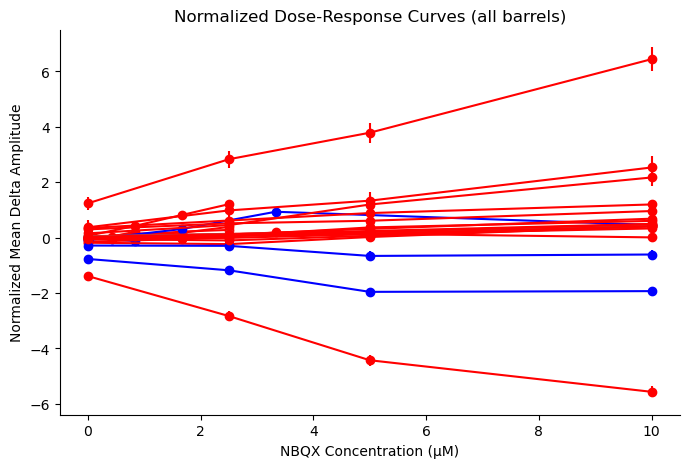

In [69]:
# take all increasing barrel traces and make a plot with the mean and SEM across 
# all increasing barrels, to see how the overall response of 
# increasing barrels changes over time with NBQX infusion

# put them all on a plot of normalized delta amplitude vs NBQX concentration, with error bars for SEM, to visualize how the 
# overall response of increasing barrels changes with NBQX concentration

# compute the delta of the amplitude for each pixel at each time-step.
# then create a heatmap of the delta amplitude for each pixel at each time-step, to visualize how the spatial pattern of responses changes over time with NBQX infusion
# only do for pixels in the 9-px ROIs, leaving all other pixels blank

group_by_conc = {'increasing': {}, 'decreasing': {}, 'flat': {}}
plt.figure(figsize=(8, 5))
for date in nine_px_df['Date'].unique():
    date_df = nine_px_df[nine_px_df['Date'] == date]
    for slic in date_df['Slice'].unique():
        slice_df = date_df[date_df['Slice'] == slic]
        stim_layer = slice_df['Stim_Layer'].values[0]
        for location in slice_df['Location'].unique():
            location_df = slice_df[slice_df['Location'] == location]
            num_times = len(location_df['time'].unique())

            barrel_traces = {}
            for roi_set in location_df['ROI_Set'].unique():
                roi_set_df = location_df[location_df['ROI_Set'] == roi_set]
                roi_set = roi_set_df['ROI_Set'].values[0]
                if 'output__masked_grid' not in roi_set:
                    continue
                barrel_traces[roi_set] = {'mean': [], 'sem': [], 'concs': []}
                date_corrected = date.split('/')[0].zfill(2) + '-' + date.split('/')[1].zfill(2) + '-' + date.split('/')[2][2:]
                roi_file_path = os.path.join(data_dir + ("L23/" if '03' in date_corrected else ""), f"{date_corrected}/converted_zda/{roi_set}.dat")

                times = np.array(roi_set_df['time'].values)
                times = pd.to_datetime(times)
                init_time = times[0]
                times = times - init_time  # convert to minutes relative to start of recording
                times = times.total_seconds() / 60  # convert to minutes

                for t in sorted(roi_set_df['time'].unique()):
                    time_df = roi_set_df[roi_set_df['time'] == t]
                    t_idx = list(roi_set_df['time'].unique()).index(t)

                    trace_point_mean = []
                    nbqx_conc_trace = []
                    for index, row in time_df.iterrows():
                        roi_number = row['ROI']
                        amp = row['amp']
                        nbqx_conc = row['NBQX_conc']
                        # get the pixel coordinates for this ROI from the ROI file

                        # convert date d/m/yyyy to dd-mm-yy to construct the file path for the ROI file
                        
                        roi_reader = ROIFileReader(roi_file_path)
                        roi_coords = roi_reader.get_roi_list()  # list of (x, y) tuples

                        # calculate the delta amplitude for this ROI compared to the first time point (baseline)
                        baseline_amp = roi_set_df[(roi_set_df['ROI'] == roi_number) & (roi_set_df['time'] == roi_set_df['time'].min())]['amp'].values[0]
                        delta_amp = (amp - baseline_amp) * 1000
                        trace_point_mean.append(delta_amp)
                        nbqx_conc_trace.append(nbqx_conc)

                    # update the barrel_traces dict with the mean delta amplitude for this barrel at this time point, to use for plotting the traces later
                    barrel_traces[roi_set]['mean'].append(np.nanmean(trace_point_mean))
                    barrel_traces[roi_set]['sem'].append(np.nanstd(trace_point_mean) / np.sqrt(len(trace_point_mean)))
                    barrel_traces[roi_set]['concs'].append(np.nanmean(nbqx_conc_trace))

                    # normalize mean and sem to max mean and min across all time points for this barrel, to visualize as normalized delta amplitude vs NBQX concentration
                    baseline = barrel_traces[roi_set]['mean'][0]
                    if baseline != 0:
                        barrel_traces[roi_set]['mean'] = [(m-baseline) / baseline for m in barrel_traces[roi_set]['mean']]
                        barrel_traces[roi_set]['sem'] = [s / baseline for s in barrel_traces[roi_set]['sem']]
    
                    for c, m in zip(barrel_traces[roi_set]['concs'], barrel_traces[roi_set]['mean']):
                        # round c to nearest 0.000001
                        c = round(c, 6)
                        # determine if this barrel is increasing, decreasing, or flat based on whether the mean at the highest concentration is more than 15% higher, more than 15% lower, or within 15% of the mean at the lowest concentration
                        if m > barrel_traces[roi_set]['mean'][0] * 1.2:
                            group_by_conc['increasing'][c] = group_by_conc['increasing'].get(c, []) + [m]
                        elif m < barrel_traces[roi_set]['mean'][0] * 0.8:
                            group_by_conc['decreasing'][c] = group_by_conc['decreasing'].get(c, []) + [m]
                        else:
                            group_by_conc['flat'][c] = group_by_conc['flat'].get(c, []) + [m]

            times = sorted(roi_set_df['time'].unique())
            times = pd.to_datetime(times)
            init_time = times[0]
            times = times - init_time  # convert to minutes relative to start of recording
            times = times.total_seconds() / 60  # convert to minutes

            for barrel in barrel_traces:
                trace = barrel_traces[barrel]['mean']
                sem = barrel_traces[barrel]['sem']
                concs = barrel_traces[barrel]['concs']

                # group by concentration and average the mean and sem for time points with the same concentration, to avoid overlapping error bars for time points with the same concentration
                conc_trace_dict = {}
                for c, m, s in zip(concs, trace, sem):
                    if c not in conc_trace_dict:
                        conc_trace_dict[c] = {'mean': [], 'sem': []}
                    conc_trace_dict[c]['mean'].append(m)
                    conc_trace_dict[c]['sem'].append(s)
                concs = []                
                trace = []
                sem = []

                # color is red if trace is increasing with concentration, blue if trace is decreasing with concentration, and gray if trace is flat, to visually link the trace to the type of dose-response curve
                trace_color = 'gray'
                if conc_trace_dict[c]['mean'][-1] > conc_trace_dict[c]['mean'][0] * 1.2:  # if the mean at the highest concentration is more than x% higher than the mean at the lowest concentration, consider it increasing
                    trace_color = 'red'
                elif conc_trace_dict[c]['mean'][-1] < conc_trace_dict[c]['mean'][0] * 0.8:  # if the mean at the highest concentration is more than x% lower than the mean at the lowest concentration, consider it decreasing
                    trace_color = 'blue'

                # scatter plot with errorbars for SEM, points not connected since the x values (concentrations) are not evenly spaced
                plt.errorbar(list(conc_trace_dict.keys()), [np.nanmean(conc_trace_dict[c]['mean']) for c in conc_trace_dict], 
                             yerr=[np.nanmean(conc_trace_dict[c]['sem']) for c in conc_trace_dict], label=barrel, color=trace_color, marker='o')

# spines off
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
#plt.ylim(-1.2, 1.2)
plt.xlabel('NBQX concentration (μM)')
plt.ylabel('Percent change in mean amplitude from baseline)')
plt.title(f"Normalized dose-response curves (all barrels)")
plt.savefig(os.path.join(output_fig_dir, f"{roi_selection}_normalized_dose_response_curves_all_barrels.png"))
plt.show()


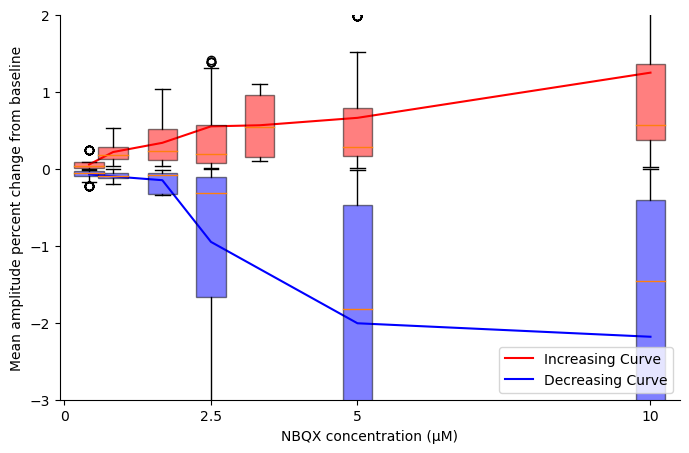

In [73]:

# a boxplot for each concentration, showing the distribution of normalized mean delta amplitude across all barrels at that concentration, to visualize how the overall response changes with NBQX concentration across barrels
plt.figure(figsize=(8, 5))
for curve_type in sorted(group_by_conc.keys()):
    for c in sorted(group_by_conc[curve_type].keys()):
        # color is red if mean is increasing with concentration, blue if mean is decreasing with concentration, and gray if mean is flat, to visually link the boxplot to the type of dose-response curve
        trace_color = 'gray'
        if curve_type == 'increasing':  # if the mean at this concentration is more than 15% higher than the mean at the lowest concentration, consider it increasing
            trace_color = 'red'
        elif curve_type == 'decreasing':  # if the mean at this concentration is more than 15% lower than the mean at the lowest concentration, consider it decreasing
            trace_color = 'blue'

        # don't plot baseline (0 μM) since all barrels are normalized to that concentration, and the distribution will be very tight around 0, which makes it hard to see the distribution at other concentrations
        if c == 0:
            continue

        plt.boxplot(group_by_conc[curve_type][c], positions=[c], widths=0.5, patch_artist=True, boxprops=dict(facecolor=trace_color, alpha=0.5))

        # also add a scatter plot of the individual points for each barrel at this concentration, to show the distribution of responses across barrels
    #x_jitter = np.random.normal(0, 0.1, size=len(group_by_conc[curve_type][c]))
    #plt.scatter(np.array(group_by_conc[curve_type][c]) + x_jitter, group_by_conc[curve_type][c], color=trace_color, alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# draw a line connecting the means at each concentration, to visualize the overall trend across concentrations, with points for each concentration colored according to whether they are increasing, decreasing, or flat
mean_by_conc = {'increasing': {}, 'decreasing': {}, 'flat': {}}
for curve_type in sorted(group_by_conc.keys()):
    for c in sorted(group_by_conc[curve_type].keys()):
        if c == 0:
            continue
        mean_by_conc[curve_type][c] = np.nanmean(group_by_conc[curve_type][c])
plt.plot(sorted(mean_by_conc['increasing'].keys()), [mean_by_conc['increasing'][c] for c in sorted(mean_by_conc['increasing'].keys())], color='red', label='Increasing Curve')
plt.plot(sorted(mean_by_conc['decreasing'].keys()), [mean_by_conc['decreasing'][c] for c in sorted(mean_by_conc['decreasing'].keys())], color='blue', label='Decreasing Curve')
if len(mean_by_conc['flat']) > 0:
    plt.plot(sorted(mean_by_conc['flat'].keys()), [mean_by_conc['flat'][c] for c in sorted(mean_by_conc['flat'].keys())], color='gray', label='Flat Curve')
plt.legend()
plt.ylim(-3, 2)
plt.xticks([0, 2.5, 5, 10], [0, 2.5, 5, 10])
plt.xlabel('NBQX concentration (μM)')
plt.ylabel('Mean amplitude percent change from baseline')
plt.savefig(os.path.join(output_fig_dir, f"{roi_selection}_normalized_dose_response_distribution_all_barrels.png"))
plt.show()

In [75]:
# gif that scrolls through each simulation NBQX/ACSF heatmap for each NBQX
# concentration, to visualize how the spatial pattern of responses changes with NBQX infusion across barrels and concentrations
partial_nbqx_fractions_map = {
    'run11_3': 1, # ACSF
    'run11_7': 0.0,
    'run13_0': 0.05,
    'run13_1': 0.1,
    'run13_2': 0.15,
    'run13_3': 0.01,
    'run13_4': 0.0,
    'run13_5': 0.2,
    'run13_6': 0.02,
    'run13_7': 0.25,
    'run13_8': 0.35,
    'run13_9': 0.15,
    #'run13_9_1': 0.15,
    'run15_00': 0.5,
    'run15_01': 0.75,
    'run15_02': 0.85,
    'run15_03': 0.65,
    'run15_04': 0.57,
    'run15_05': 0.95,
}
data_base_dir = 'P:/John/simulation/in-silico-hVOS/neuron docker/composed_results/'
conc_to_image_map = {}
for sim in partial_nbqx_fractions_map:
    conc = partial_nbqx_fractions_map[sim]
    image_path = os.path.join(data_base_dir, sim, f'{sim}_and_run11_3', f'amplitude_ratio_histogram_layer_{sim}_and_run11_3_dend_apic.png')
    print(f"Looking for image at {image_path} for simulation {sim} with concentration {conc}")
    if os.path.exists(image_path):
        conc_to_image_map[conc] = imageio.imread(image_path)
    else:
        print(f"Image not found for {sim} at {image_path}")

# sort the conc_to_image_map by concentration
conc_to_image_map = dict(sorted(conc_to_image_map.items()))
# create a gif that scrolls through the images in conc_to_image_map in order of concentration
image_file_list = list(conc_to_image_map.values())
movie_filename = os.path.join(output_fig_dir, f"simulation_nbqx_dose_response_maps_by_layer.gif")

try:
    imageio.mimsave(movie_filename, image_file_list, duration=0.5)
    print("CREATED MOVIE:", movie_filename)
except Exception as e:
    print("Not creating movie for " + movie_filename)
    print(e)


Looking for image at P:/John/simulation/in-silico-hVOS/neuron docker/composed_results/run11_3\run11_3_and_run11_3\amplitude_ratio_histogram_layer_run11_3_and_run11_3_dend_apic.png for simulation run11_3 with concentration 1
Image not found for run11_3 at P:/John/simulation/in-silico-hVOS/neuron docker/composed_results/run11_3\run11_3_and_run11_3\amplitude_ratio_histogram_layer_run11_3_and_run11_3_dend_apic.png
Looking for image at P:/John/simulation/in-silico-hVOS/neuron docker/composed_results/run11_7\run11_7_and_run11_3\amplitude_ratio_histogram_layer_run11_7_and_run11_3_dend_apic.png for simulation run11_7 with concentration 0.0
Image not found for run11_7 at P:/John/simulation/in-silico-hVOS/neuron docker/composed_results/run11_7\run11_7_and_run11_3\amplitude_ratio_histogram_layer_run11_7_and_run11_3_dend_apic.png
Looking for image at P:/John/simulation/in-silico-hVOS/neuron docker/composed_results/run13_0\run13_0_and_run11_3\amplitude_ratio_histogram_layer_run13_0_and_run11_3_dend

76 247
0 76


C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[roi_df['halfwidth'] > 20] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

1 247


C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:38: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[roi_df['halfwidth'] > 20] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

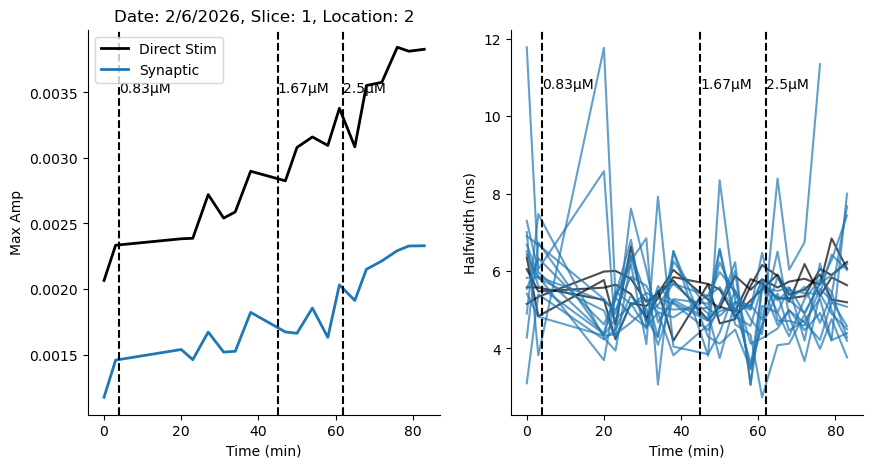

C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[roi_df['halfwidth'] > 20] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

92 207
0 92
1 207


C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:58: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:38: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

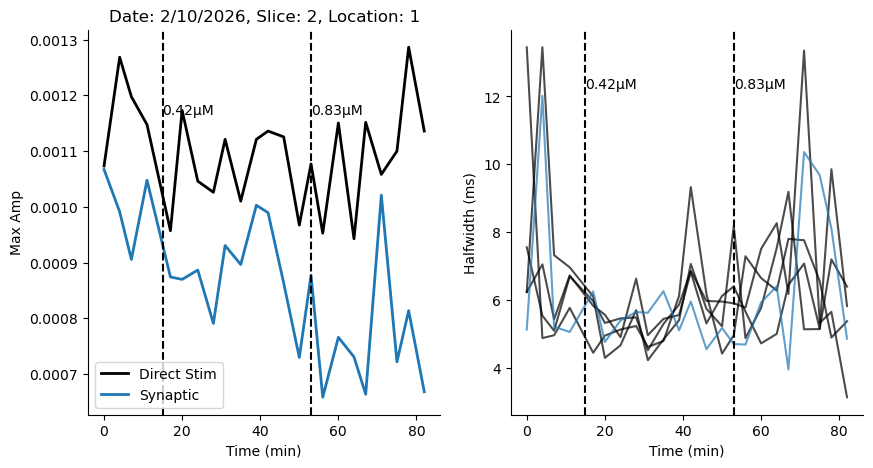

C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[roi_df['halfwidth'] > 20] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

210 330
0 210
1 330


C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:52: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 2)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:38: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

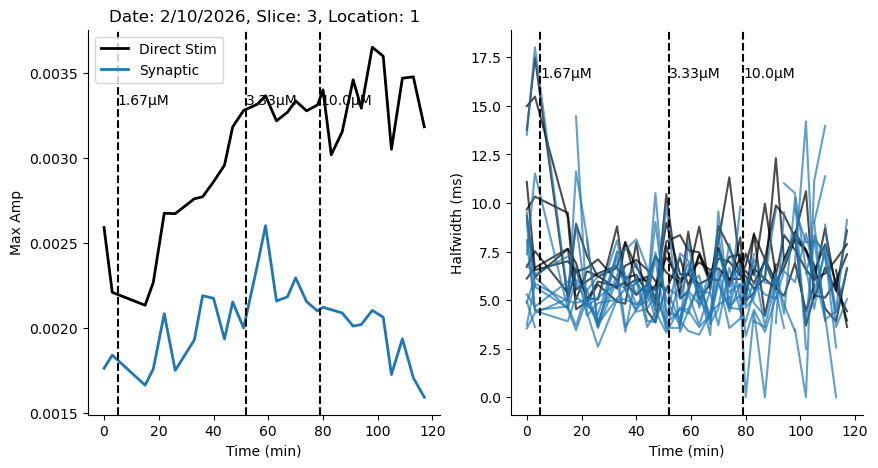

C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[roi_df['halfwidth'] > 20] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

148 333
0 148
1 333


C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:38: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_23160\349296491.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[roi_df['halfwidth'] > 20] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

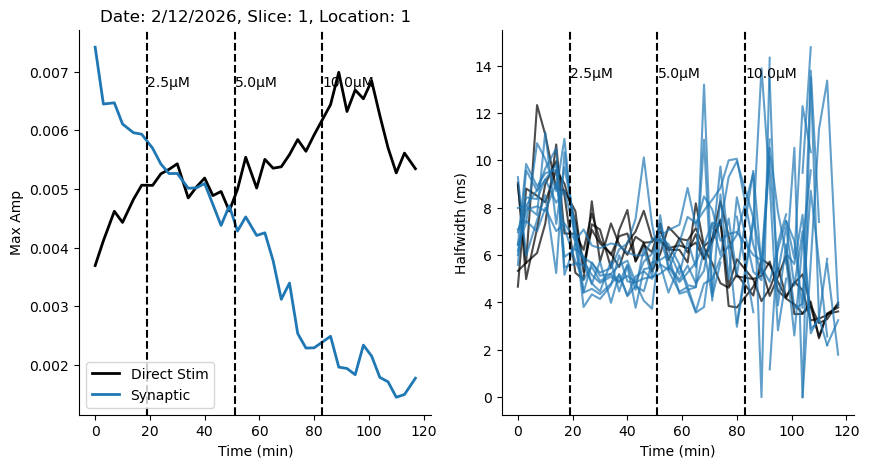

In [12]:
# direct_df 
average_trace_of_direct = True

for df in [direct_df]:
    for date in df['Date'].unique():
        date_df = df[df['Date'] == date]
        for slic in date_df['Slice'].unique():
            slice_df = date_df[date_df['Slice'] == slic]
            for location in slice_df['Location'].unique():

                plt.subplots(1, 2, figsize=(10, 5))
                location_df = slice_df[slice_df['Location'] == location]

                # divide into direct and indirect, based on if "indirect" is in the ROI_Set column
                x_indirect_df = location_df[location_df['ROI_Set'].str.contains("indirect", case=False)]
                x_direct_df = location_df[~location_df['ROI_Set'].str.contains("indirect", case=False)]
                
                print(len(x_direct_df), len(x_indirect_df))
                dir_color = ['black', 'tab:blue', ]
                for i_dir, dir_df in enumerate([x_direct_df, x_indirect_df]):
                    print(i_dir, len(dir_df))
                    avg_trace = []
                    for roi in dir_df['ROI'].unique():
                        roi_df = dir_df[dir_df['ROI'] == roi]
                        # ROI Set value
                        roi_set = roi_df['ROI_Set'].values[0]

                        times = np.array(roi_df['time'].values)
                        # convert times to time datatype to allow subtraction
                        times = pd.to_datetime(times)
                        init_time = times[0]
                        times = times - init_time  # convert to minutes relative to start of recording
                        times = times.total_seconds() / 60  # convert to minutes

                        # in subplot 1, plot the max_amp vs time
                        # each date, slic, location, recording is a different line in meta_catalog, where time can be looked up

                        plt.subplot(1, 2, 1)
                        if not average_trace_of_direct:
                            plt.plot(times, roi_df['amp'], label="Direct Stim" if i_dir == 0 else "Synaptic", color=dir_color[i_dir], alpha=0.7)

                        plt.xlabel('Time (min)')
                        plt.ylabel('Max Amp')
                        plt.title(f"Date: {date}, Slice: {slic}, Location: {location}")
                        
                        # filter halfwidths > 20
                        roi_df[roi_df['halfwidth'] > 20] = np.nan
                        # stricter halfwidth filter for low-amplitude (late / high NBQX) responses
                        roi_df[(roi_df['NBQX_conc'] > 2) & (roi_df['halfwidth'] > 15)] = np.nan
                        # in subplot 2, plot halfwidth vs time
                        if roi == 1 or np.mean(roi_df['amp']) > 0.001:  # only plot halfwidth for ROI 1 or if mean amp is above threshold
                            plt.subplot(1, 2, 2)
                            plt.plot(times, roi_df['halfwidth'], color=dir_color[i_dir], alpha=0.7)
                            plt.xlabel('Time (min)')
                            plt.ylabel('Halfwidth (ms)')
                    if average_trace_of_direct:
                        avg_trace = dir_df.groupby('time')['amp'].mean().reset_index()
                        plt.subplot(1, 2, 1)
                        plt.plot(times, avg_trace['amp'], label="Direct Stim" if i_dir == 0 else "Synaptic", color=dir_color[i_dir], linewidth=2)

                # nbqx times table to mark when each new concentration of NBQX was infused
                nbqx_times = roi_df[['NBQX_conc', 'infusion_time']].drop_duplicates()
                nbqx_conc = nbqx_times['NBQX_conc'].values
                nbqx_times = nbqx_times['infusion_time'].values
                nbqx_times = pd.to_datetime(np.array(nbqx_times))
                nbqx_times -= init_time
                nbqx_times = nbqx_times.total_seconds() / 60  # convert to minutes
                
                # mark nbqx infusion times on the plots
                for i in range(len(nbqx_times)):
                    # as vertical lines with text indicating the concentration
                    for j in range(1, 3):
                        plt.subplot(1, 2, j)
                        plt.axvline(x=nbqx_times[i], color='black', linestyle='--')
                        plt.text(nbqx_times[i], plt.ylim()[1]*0.9, f"{nbqx_conc[i]}μM", 
                                color='black', va='top', ha='left')
                plt.subplot(1, 2, 1)
                # only keep first and last handle in legend
                handles, labels = plt.gca().get_legend_handles_labels()
                if len(handles) > 2:
                    handles = [handles[0], handles[-1]]
                    labels = [labels[0], labels[-1]]
                plt.legend(handles, labels)

                # remove top and right spines
                plt.subplot(1, 2, 1)
                plt.gca().spines['top'].set_visible(False)
                plt.gca().spines['right'].set_visible(False)
                plt.subplot(1, 2, 2)
                plt.gca().spines['top'].set_visible(False)
                plt.gca().spines['right'].set_visible(False)
                
                plt.show()
                    